In [8]:
import pandas as pd
import random
import os
import matplotlib.pyplot as plt

ROOT = ".." # Adjust to repository root
PRICE_PATH = os.path.join(ROOT, "datasets", "daep")
LOAD_PATH = os.path.join(ROOT, "datasets", "weld")
CSV_DIR = os.path.join(ROOT, "csv")
WEATHER_STATS_DIR = os.path.join(CSV_DIR, "stats")

## 1-year data plots

### 2015

In [2]:
prices_2015 = pd.read_csv(os.path.join(PRICE_PATH, 'Spain_ENTSO-E_2015.csv'))
prices_2015['Timestamp'] = pd.to_datetime(prices_2015['Timestamp'])
prices_2015.rename(columns={'Spain': 'Price'}, inplace=True)
display(prices_2015.head(2))
print("...")
display(prices_2015.tail(2))

,Timestamp,Price
0,2015-01-01 00:00:00,50.1
1,2015-01-01 01:00:00,48.1


...


,Timestamp,Price
8758,2015-12-31 22:00:00,56.70
8759,2015-12-31 23:00:00,50.95


In [3]:
load_2015 = pd.read_csv(os.path.join(LOAD_PATH, 'Spain_ENTSO-E_2015.csv'))
load_2015['Timestamp'] = pd.to_datetime(load_2015['Timestamp'])
load_2015.rename(columns={'Spain': 'Load'}, inplace=True)
display(load_2015.head(2))
print("...")
display(load_2015.tail(2))

,Timestamp,Load
0,2015-01-01 00:00:00,25385.0
1,2015-01-01 01:00:00,24382.0


...


,Timestamp,Load
8759,2015-12-31 22:00:00,24565.0
8760,2015-12-31 23:00:00,23311.0


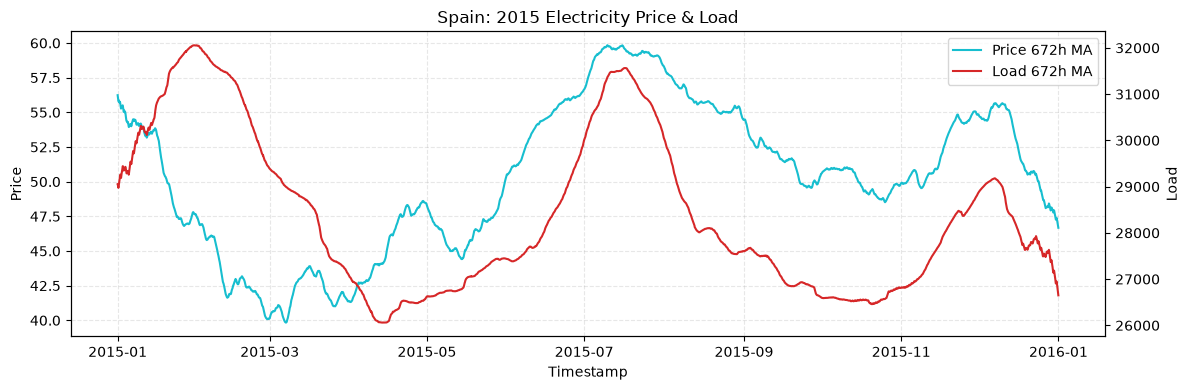

In [4]:
price_col = prices_2015.select_dtypes(include="number").columns[0]
load_col = load_2015.select_dtypes(include="number").columns[0]

rolling_window = 24*28
ma_price_col = f"{price_col}_MA{rolling_window}"
prices_2015[ma_price_col] = prices_2015[price_col].rolling(window=rolling_window, min_periods=1, center=True).mean()

ma_load_col = f"{load_col}_MA{rolling_window}"
load_2015[ma_load_col] = load_2015[load_col].rolling(window=rolling_window, min_periods=1, center=True).mean()

fig, ax_price = plt.subplots(figsize=(12, 4))
line_price_ma, = ax_price.plot(prices_2015["Timestamp"], prices_2015[ma_price_col],
                               color="tab:cyan", linestyle="-", label=f"{price_col} {rolling_window}h MA")
ax_price.set_ylabel("Price")

ax_load = ax_price.twinx()
line_load_ma, = ax_load.plot(load_2015["Timestamp"], load_2015[ma_load_col],
                             color="tab:red", linestyle="-", label=f"{load_col} {rolling_window}h MA")
ax_load.set_ylabel("Load")

ax_price.set_title(f"Spain: 2015 Electricity Price & Load")
ax_price.set_xlabel("Timestamp")
ax_price.grid(True, linestyle="--", alpha=0.3)

lines = [line_price_ma, line_load_ma]
ax_price.legend(lines, [line.get_label() for line in lines], loc="best")

plt.tight_layout()

### All yearly series

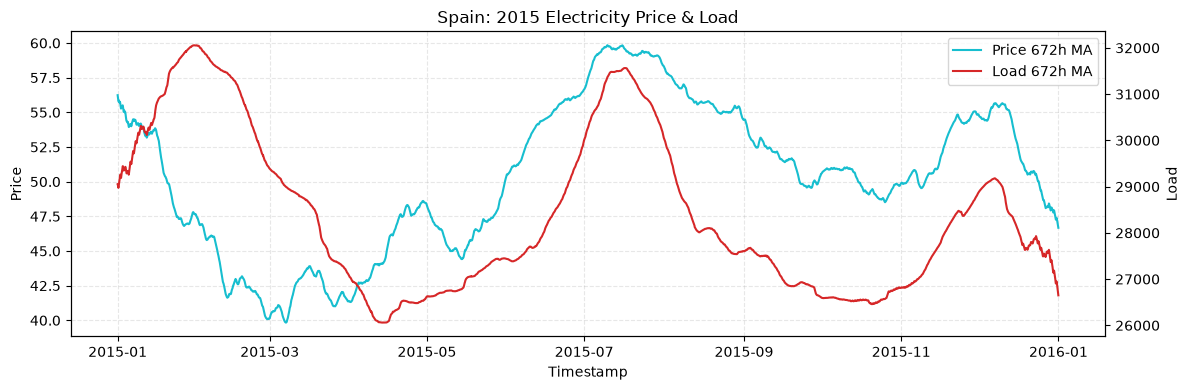

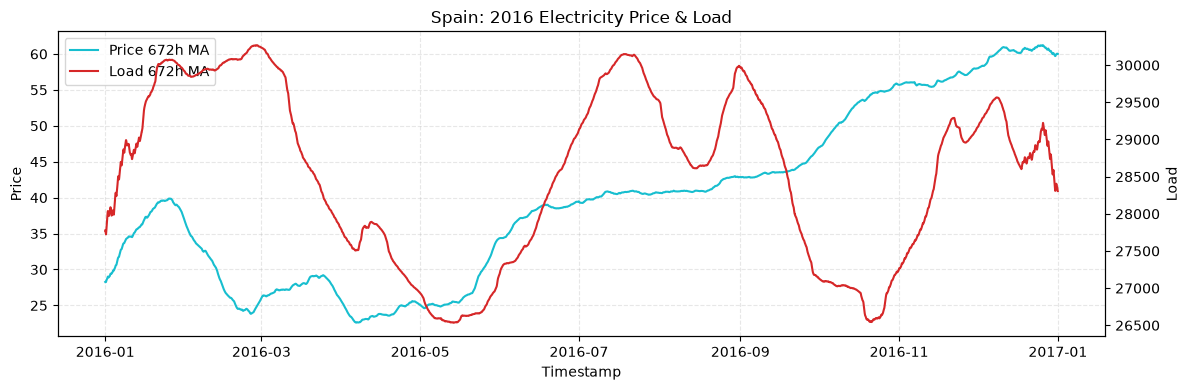

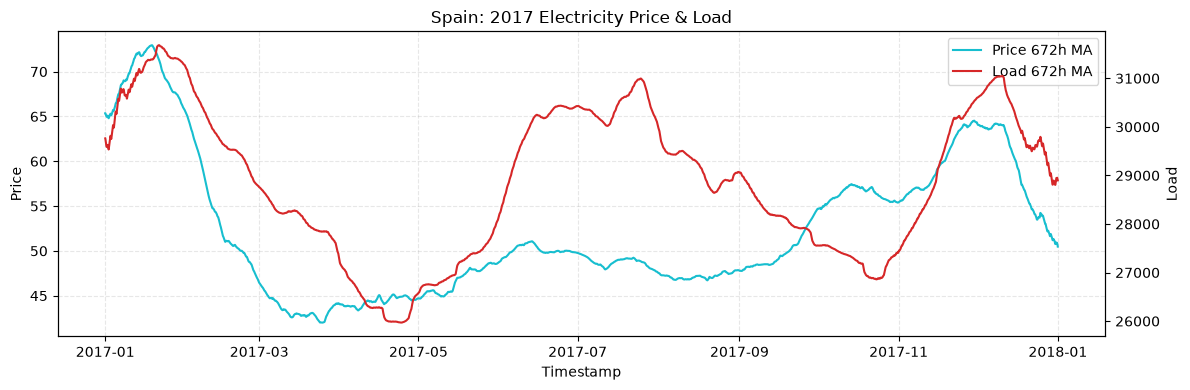

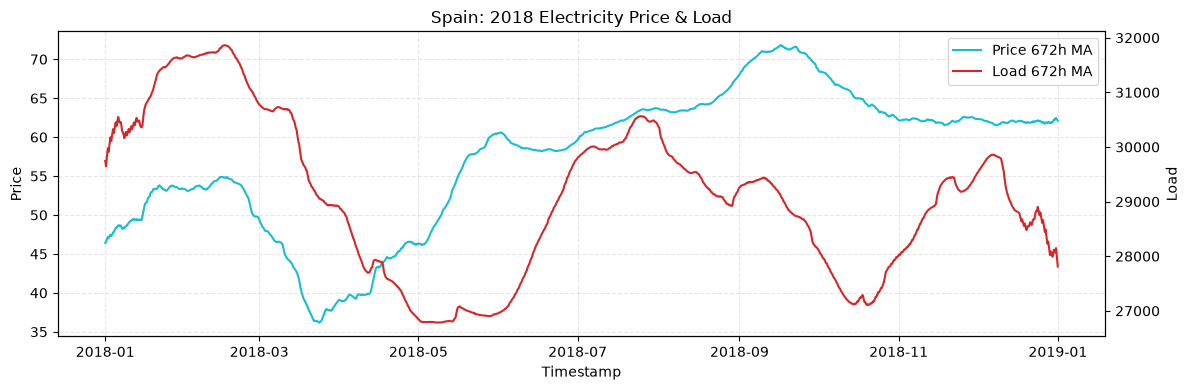

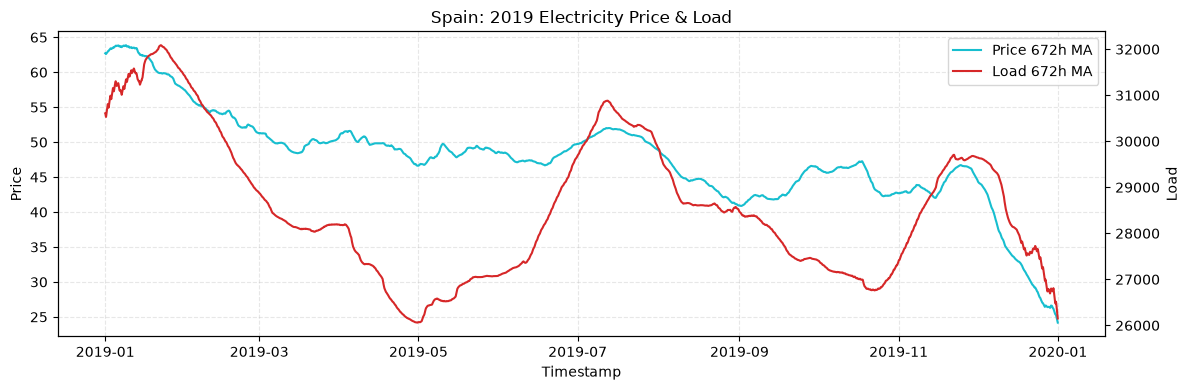

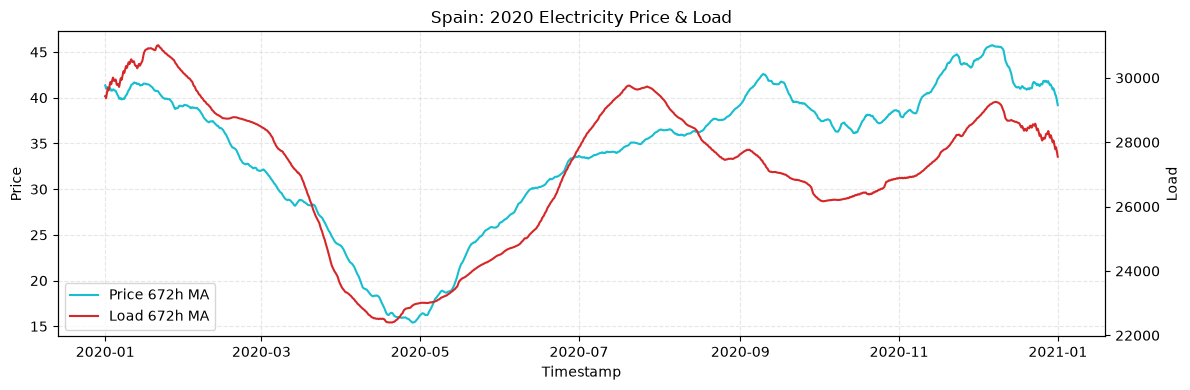

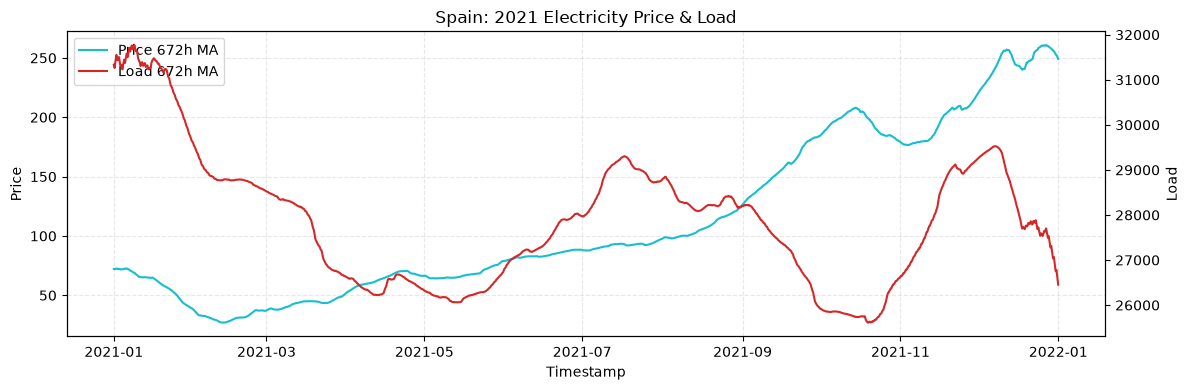

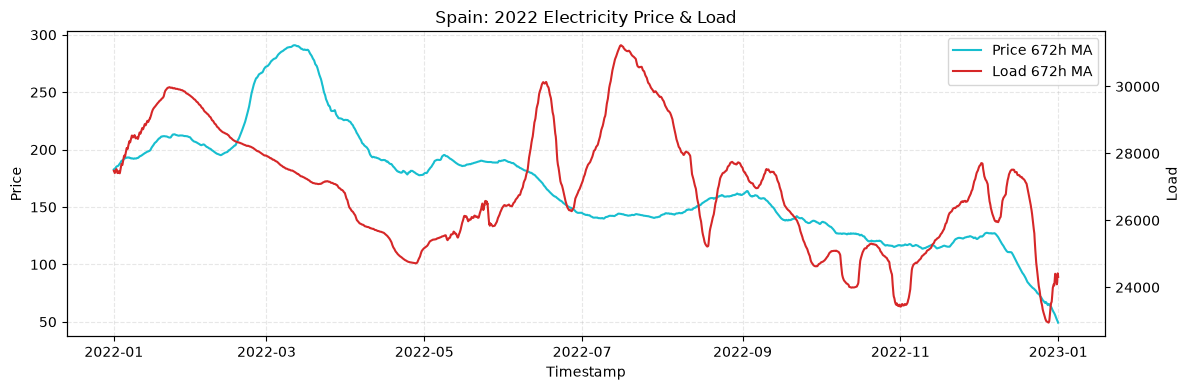

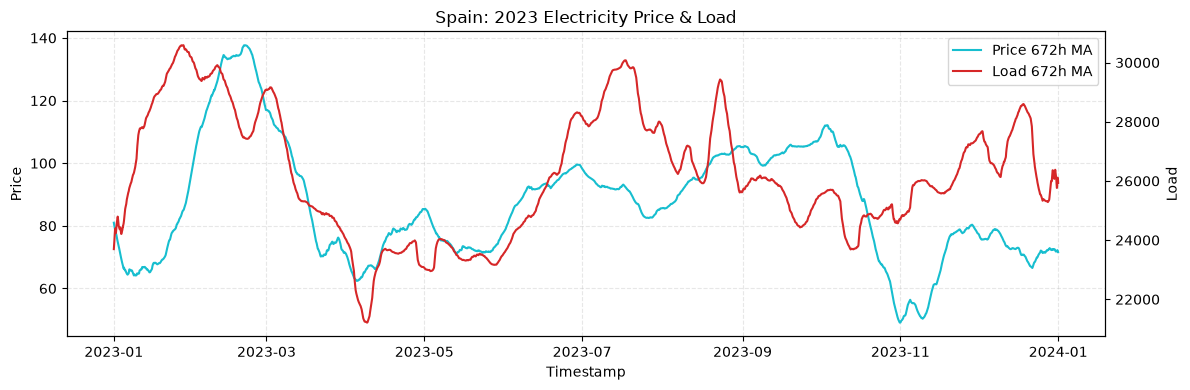

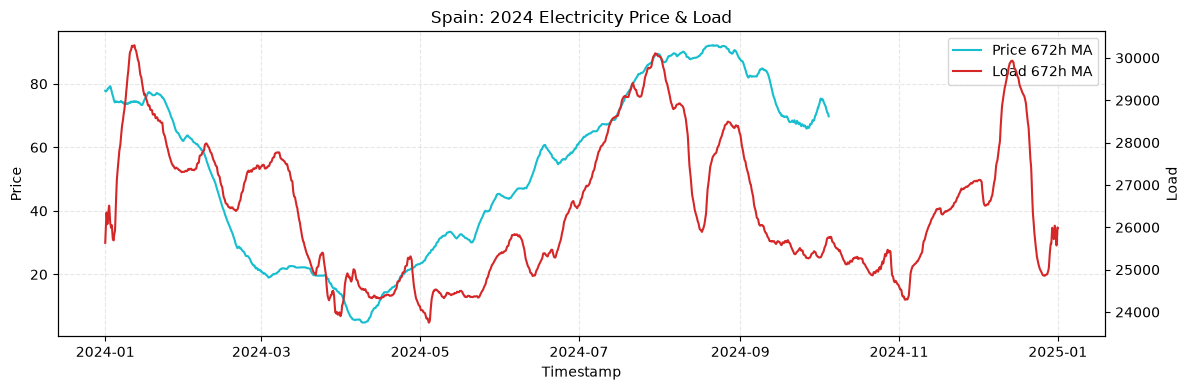

In [5]:
def plot_year_price_and_load(year, rolling_window=24 * 28):
    prices_year = pd.read_csv(os.path.join(PRICE_PATH, f"Spain_ENTSO-E_{year}.csv"))
    load_year = pd.read_csv(os.path.join(LOAD_PATH, f"Spain_ENTSO-E_{year}.csv"))

    prices_year["Timestamp"] = pd.to_datetime(prices_year["Timestamp"])
    load_year["Timestamp"] = pd.to_datetime(load_year["Timestamp"])
    prices_year.rename(columns={"Spain": "Price"}, inplace=True)
    load_year.rename(columns={"Spain": "Load"}, inplace=True)

    price_col = prices_year.select_dtypes(include="number").columns[0]
    load_col = load_year.select_dtypes(include="number").columns[0]
    ma_price_col = f"{price_col}_MA{rolling_window}"
    ma_load_col = f"{load_col}_MA{rolling_window}"

    prices_year[ma_price_col] = prices_year[price_col].rolling(
        window=rolling_window, min_periods=1, center=True
    ).mean()
    load_year[ma_load_col] = load_year[load_col].rolling(
        window=rolling_window, min_periods=1, center=True
    ).mean()

    fig, ax_price = plt.subplots(figsize=(12, 4))
    line_price, = ax_price.plot(
        prices_year["Timestamp"],
        prices_year[ma_price_col],
        color="tab:cyan",
        label=f"{price_col} {rolling_window}h MA",
    )
    ax_price.set_ylabel("Price")
    ax_price.set_xlabel("Timestamp")
    ax_price.grid(True, linestyle="--", alpha=0.3)

    ax_load = ax_price.twinx()
    line_load, = ax_load.plot(
        load_year["Timestamp"],
        load_year[ma_load_col],
        color="tab:red",
        label=f"{load_col} {rolling_window}h MA",
    )
    ax_load.set_ylabel("Load")

    ax_price.set_title(f"Spain: {year} Electricity Price & Load")
    ax_price.legend(
        [line_price, line_load],
        [line.get_label() for line in [line_price, line_load]],
        loc="best",
    )
    fig.tight_layout()
    return fig, (prices_year, load_year)

yearly_price_load_plots = {
    year: plot_year_price_and_load(year)
    for year in range(2015, 2025)
}

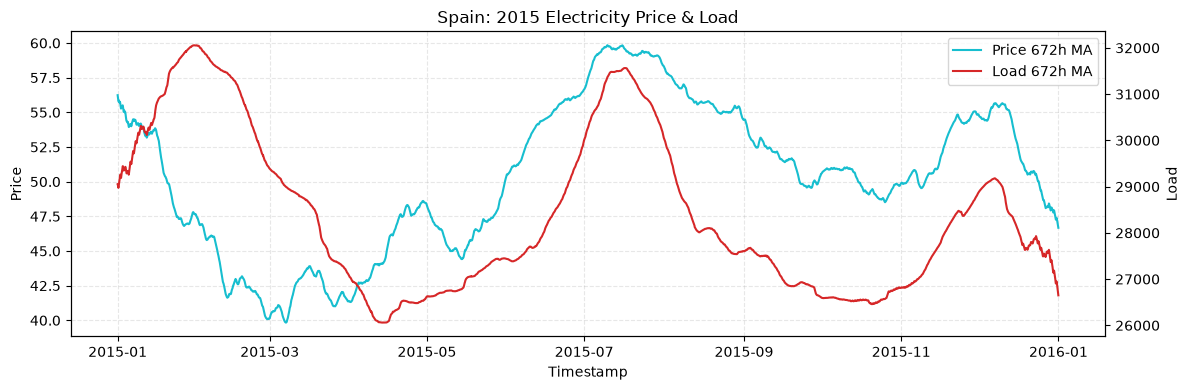

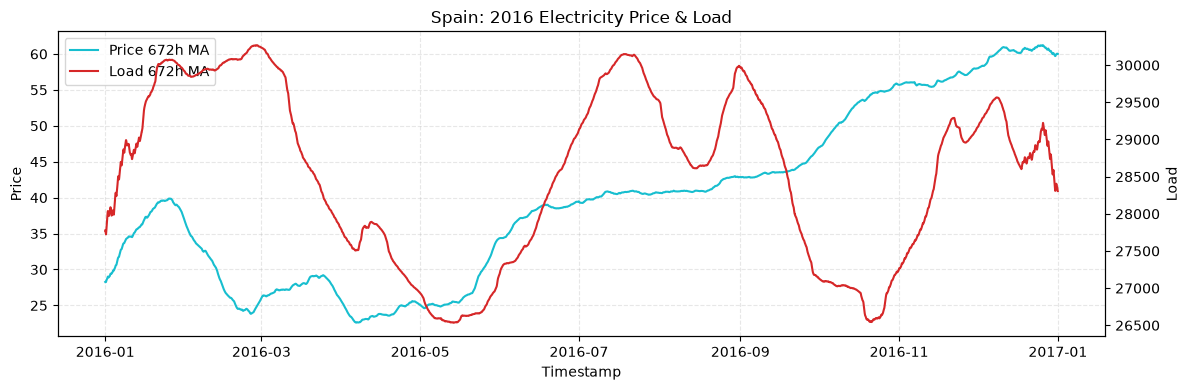

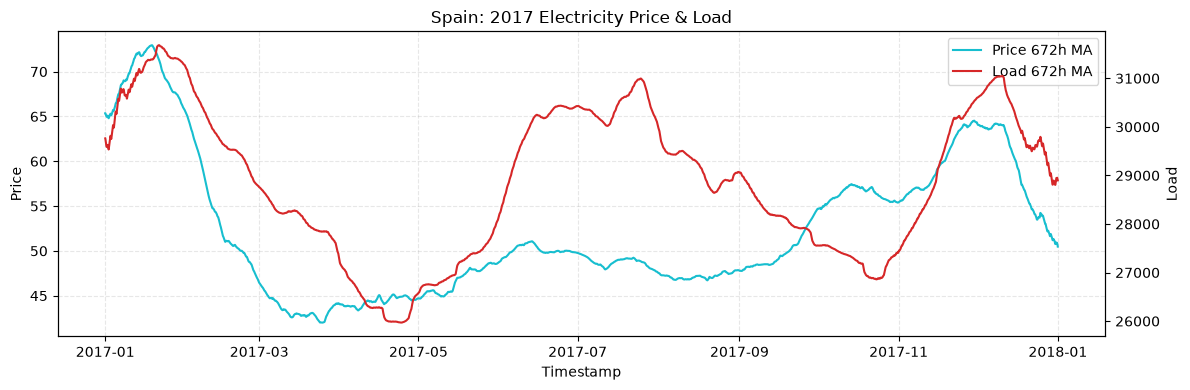

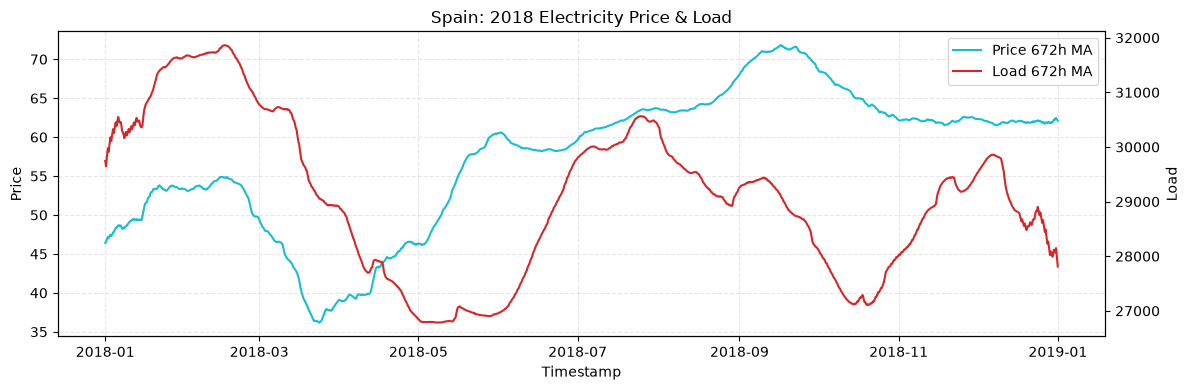

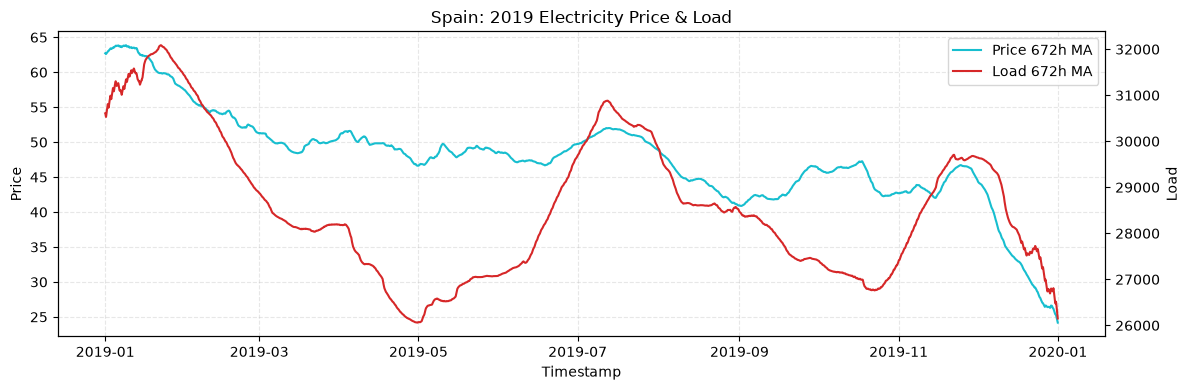

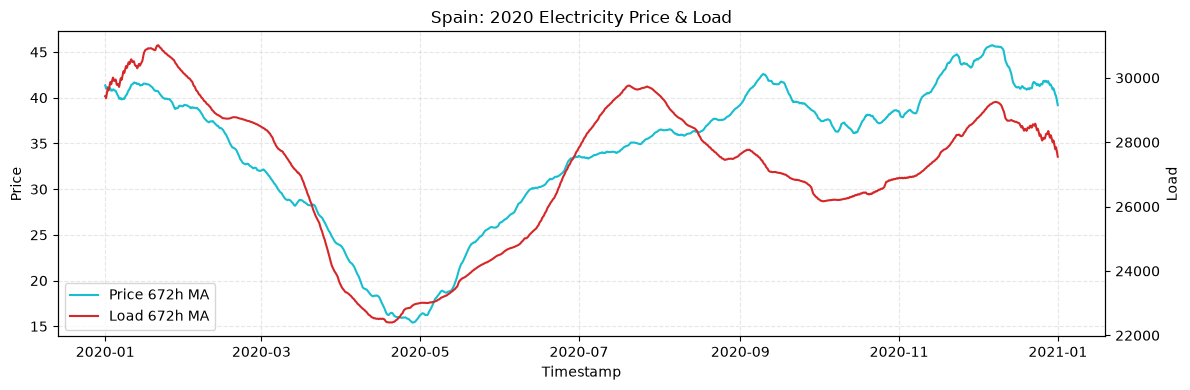

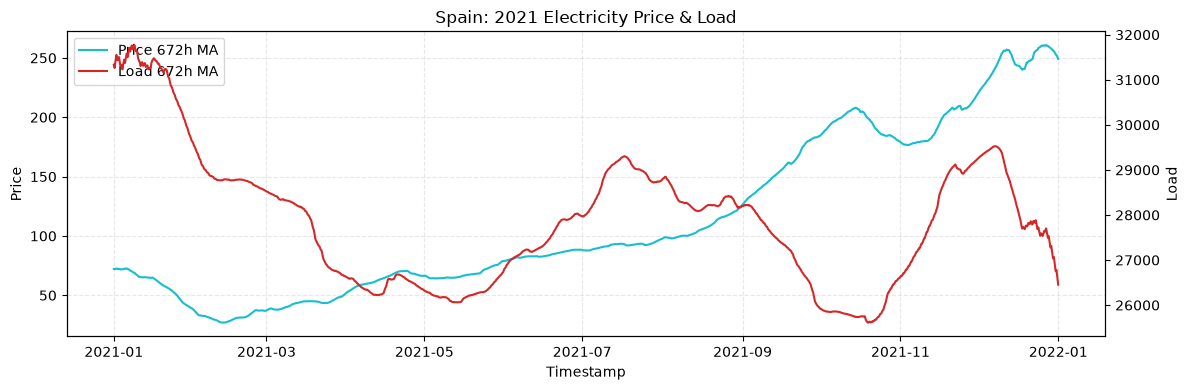

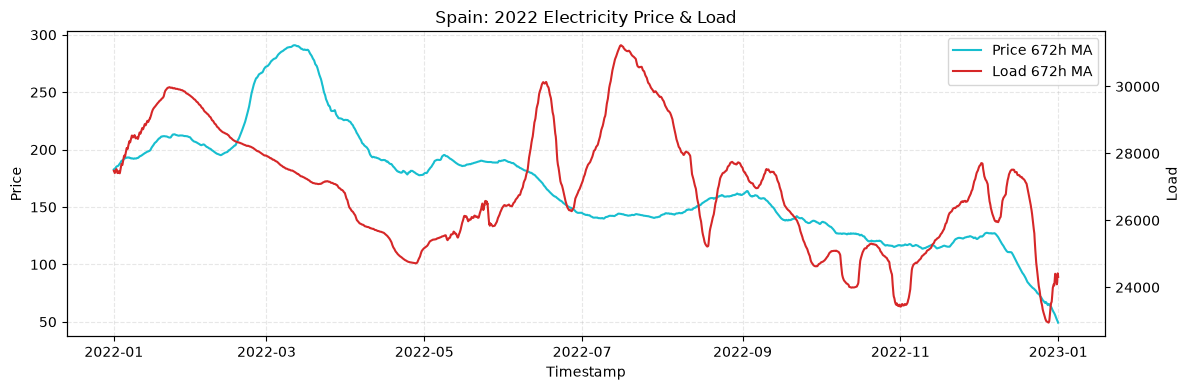

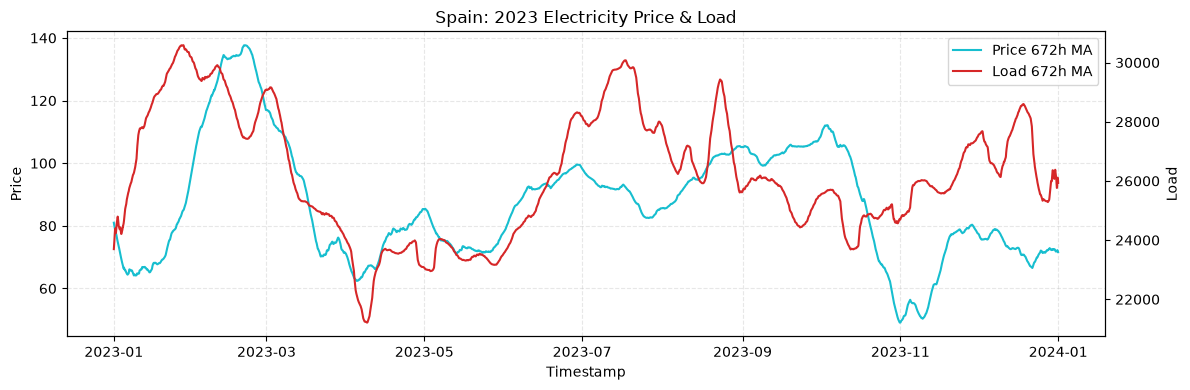

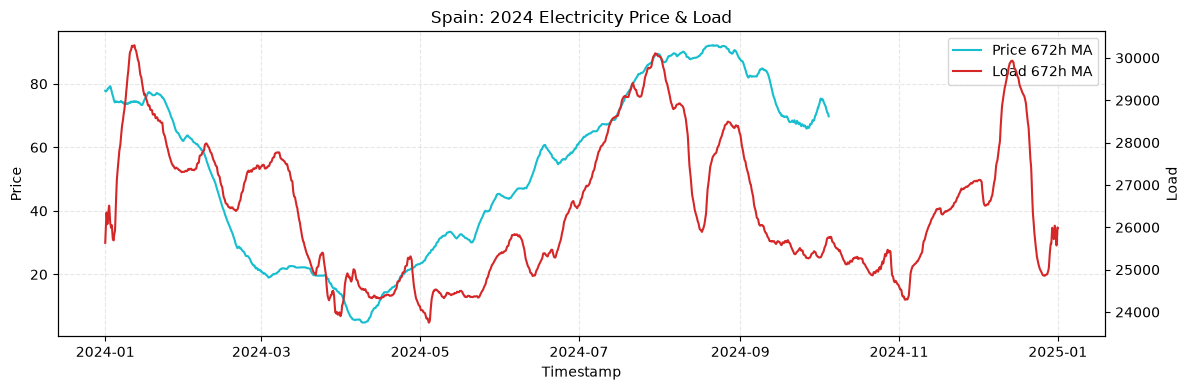

## Complete time series

In [2]:
prices = pd.concat([
    pd.read_csv(os.path.join(PRICE_PATH, f'Spain_ENTSO-E_{year}.csv'))
    for year in range(2015, 2025)
], ignore_index=True)
prices['Timestamp'] = pd.to_datetime(prices['Timestamp'])
prices.rename(columns={'Spain': 'Price'}, inplace=True)
display(prices.head(2))
print("...")
display(prices.tail(2))

,Timestamp,Price
0,2015-01-01 00:00:00,50.1
1,2015-01-01 01:00:00,48.1


...


,Timestamp,Price
85558,2024-10-04 22:00:00,117.17
85559,2024-10-04 23:00:00,115.00


In [3]:
load = pd.concat([
    pd.read_csv(os.path.join(LOAD_PATH, f'Spain_ENTSO-E_{year}.csv'))
    for year in range(2015, 2025)
], ignore_index=True)
load['Timestamp'] = pd.to_datetime(load['Timestamp'])
load.rename(columns={'Spain': 'Load'}, inplace=True)
display(load.head(2))
print("...")
display(load.tail(2))

,Timestamp,Load
0,2015-01-01 00:00:00,25385.0
1,2015-01-01 01:00:00,24382.0


...


,Timestamp,Load
156371,2024-12-31 23:30:00,24192.0
156372,2024-12-31 23:45:00,23888.0


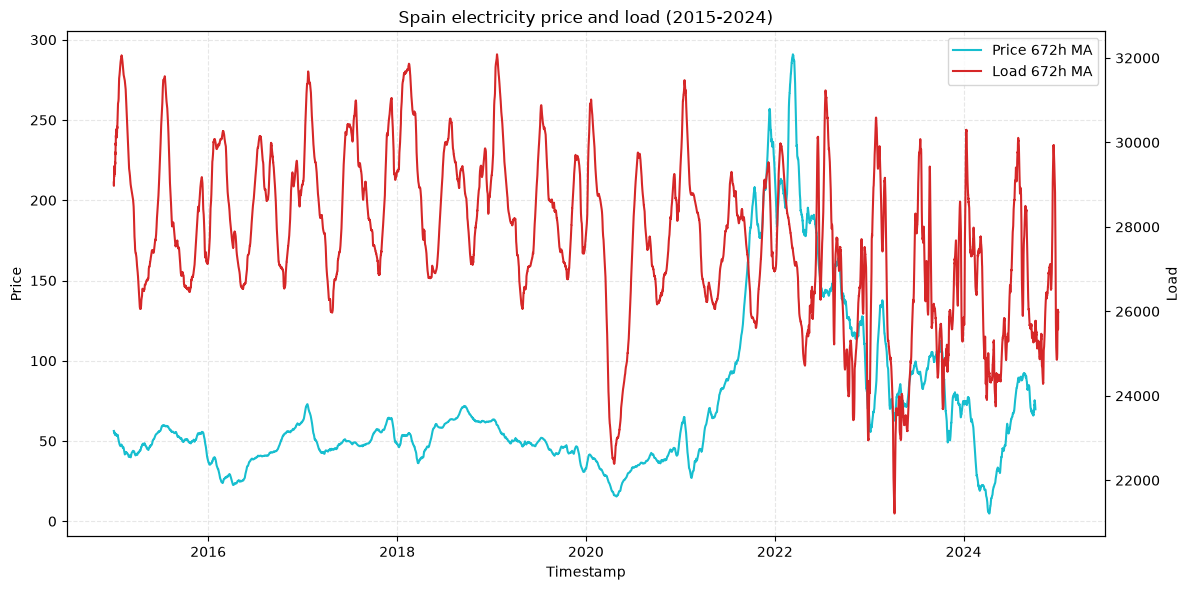

In [5]:
price_col = prices.select_dtypes(include="number").columns[0]
load_col = load.select_dtypes(include="number").columns[0]

rolling_window = 24*28
ma_price_col = f"{price_col}_MA{rolling_window}"
prices[ma_price_col] = prices[price_col].rolling(window=rolling_window, min_periods=1, center=True).mean()

ma_load_col = f"{load_col}_MA{rolling_window}"
load[ma_load_col] = load[load_col].rolling(window=rolling_window, min_periods=1, center=True).mean()

fig, ax_price = plt.subplots(figsize=(12, 6))
line_price_ma, = ax_price.plot(prices["Timestamp"], prices[ma_price_col],
                               color="tab:cyan", linestyle="-", label=f"{price_col} {rolling_window}h MA")
ax_price.set_ylabel("Price")

ax_load = ax_price.twinx()
line_load_ma, = ax_load.plot(load["Timestamp"], load[ma_load_col],
                             color="tab:red", linestyle="-", label=f"{load_col} {rolling_window}h MA")
ax_load.set_ylabel("Load")

ax_price.set_title(f"Spain electricity price and load (2015-2024)")
ax_price.set_xlabel("Timestamp")
ax_price.grid(True, linestyle="--", alpha=0.3)

lines = [line_price_ma, line_load_ma]
ax_price.legend(lines, [line.get_label() for line in lines], loc="best")

plt.tight_layout()

## Electric market and weather metrics

In [9]:
ANOMALIES_DIR = os.path.join(WEATHER_STATS_DIR, "anomalies-by-station")
tmin_anomalies = pd.read_csv(os.path.join(ANOMALIES_DIR, "tmin_anomalies.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmin: ", tmin_anomalies.shape, f"{tmin_anomalies.index.min().strftime("%Y-%m-%d")} → {tmin_anomalies.index.max().strftime("%Y-%m-%d")}")
tmax_anomalies = pd.read_csv(os.path.join(ANOMALIES_DIR, "tmax_anomalies.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmax: ", tmax_anomalies.shape, f"{tmax_anomalies.index.min().strftime("%Y-%m-%d")} → {tmax_anomalies.index.max().strftime("%Y-%m-%d")}")
tmed_anomalies = pd.read_csv(os.path.join(ANOMALIES_DIR, "tmed_anomalies.csv"), index_col="fecha", parse_dates=["fecha"],)
print("tmed: ", tmed_anomalies.shape, f"{tmed_anomalies.index.min().strftime("%Y-%m-%d")} → {tmed_anomalies.index.max().strftime("%Y-%m-%d")}")
prec_anomalies = pd.read_csv(os.path.join(ANOMALIES_DIR, "prec_anomalies.csv"), index_col="fecha", parse_dates=["fecha"],)
print("prec: ", prec_anomalies.shape, f"{prec_anomalies.index.min().strftime("%Y-%m-%d")} → {prec_anomalies.index.max().strftime("%Y-%m-%d")}")
velm_anomalies = pd.read_csv(os.path.join(ANOMALIES_DIR, "velm_anomalies.csv"), index_col="fecha", parse_dates=["fecha"],)
print("velm: ", velm_anomalies.shape, f"{velm_anomalies.index.min().strftime("%Y-%m-%d")} → {velm_anomalies.index.max().strftime("%Y-%m-%d")}")

tmin:  (4159, 691) 2015-01-01 → 2026-05-21
tmax:  (4159, 691) 2015-01-01 → 2026-05-21
tmed:  (4159, 691) 2015-01-01 → 2026-05-21
prec:  (4159, 685) 2015-01-01 → 2026-05-21
velm:  (4159, 581) 2015-01-01 → 2026-05-21


### Temperature anomalies charts

In [10]:
def plot_year_elec_and_tmed(
    year,
    elec_rolling_window=24 * 28,
    weather_rolling_window=30,
):
    prices_year = pd.read_csv(os.path.join(PRICE_PATH, f"Spain_ENTSO-E_{year}.csv"))
    load_year = pd.read_csv(os.path.join(LOAD_PATH, f"Spain_ENTSO-E_{year}.csv"))

    prices_year["Timestamp"] = pd.to_datetime(prices_year["Timestamp"])
    load_year["Timestamp"] = pd.to_datetime(load_year["Timestamp"])
    prices_year.rename(columns={"Spain": "Price"}, inplace=True)
    load_year.rename(columns={"Spain": "Load"}, inplace=True)

    price_col = prices_year.select_dtypes(include="number").columns[0]
    load_col = load_year.select_dtypes(include="number").columns[0]
    prices_year["Price_MA"] = prices_year[price_col].rolling(
        window=elec_rolling_window, min_periods=1, center=True
    ).mean()
    load_year["Load_MA"] = load_year[load_col].rolling(
        window=elec_rolling_window, min_periods=1, center=True
    ).mean()

    tmed_year = tmed_anomalies.loc[tmed_anomalies.index.year == year]
    tmed_mean = tmed_year.mean(axis=1)
    tmed_mean_ma = tmed_mean.rolling(
        window=weather_rolling_window, min_periods=1, center=True
    ).mean()

    fig, ax_price = plt.subplots(figsize=(12, 5))
    line_price, = ax_price.plot(
        prices_year["Timestamp"],
        prices_year["Price_MA"],
        color="gold",
        label=f"Price {elec_rolling_window}h MA",
    )
    ax_price.set_ylabel("Price")
    ax_price.set_xlabel("Timestamp")
    ax_price.grid(True, linestyle="--", alpha=0.3)

    month_ticks = pd.date_range(
        start=f"{year}-01-01", end=f"{year}-12-01", freq="MS"
    )
    ax_price.set_xticks(month_ticks)
    ax_price.set_xticklabels(month_ticks.strftime("%b"), rotation=45, ha="right")

    ax_load = ax_price.twinx()
    line_load, = ax_load.plot(
        load_year["Timestamp"],
        load_year["Load_MA"],
        color="blue",
        label=f"Load {elec_rolling_window}h MA",
    )
    ax_load.set_ylabel("Load")

    ax_tmed = ax_price.twinx()
    ax_tmed.spines["right"].set_position(("axes", 1.1))
    line_tmed, = ax_tmed.plot(
        tmed_mean_ma.index,
        tmed_mean_ma,
        color="red",
        label=f"Mean temp. anomaly {weather_rolling_window}d MA",
    )
    ax_tmed.set_ylabel(f"Mean temp. anomaly ({weather_rolling_window}d MA)")

    ax_price.set_title(
        f"Spain: {year} Electricity Price, Load & Daily Mean Temperature Anomaly"
    )
    lines = [line_price, line_load, line_tmed]
    ax_price.legend(lines, [line.get_label() for line in lines], loc="best")
    fig.tight_layout()
    plt.show()

    return fig, (prices_year, load_year, tmed_mean_ma)

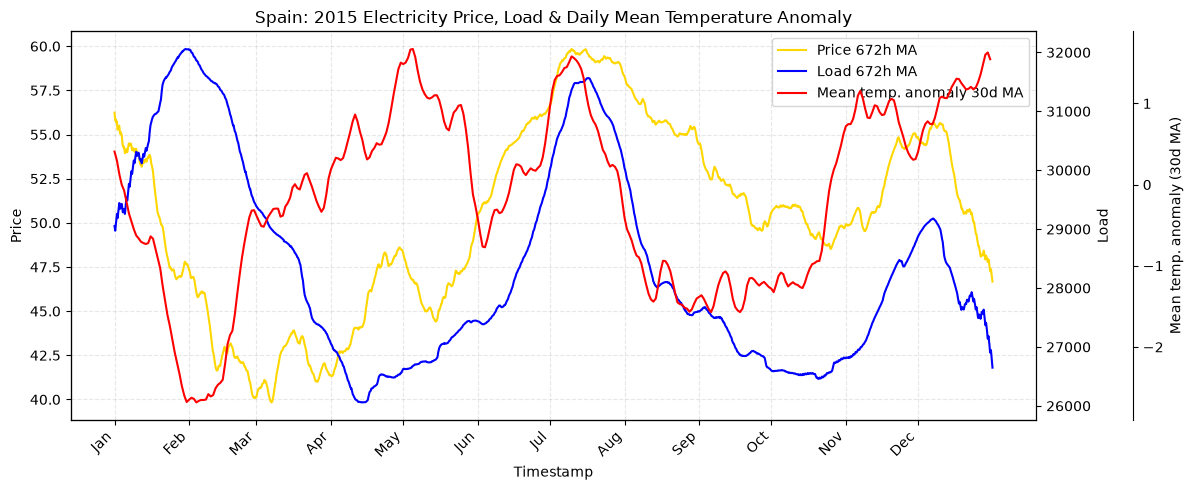

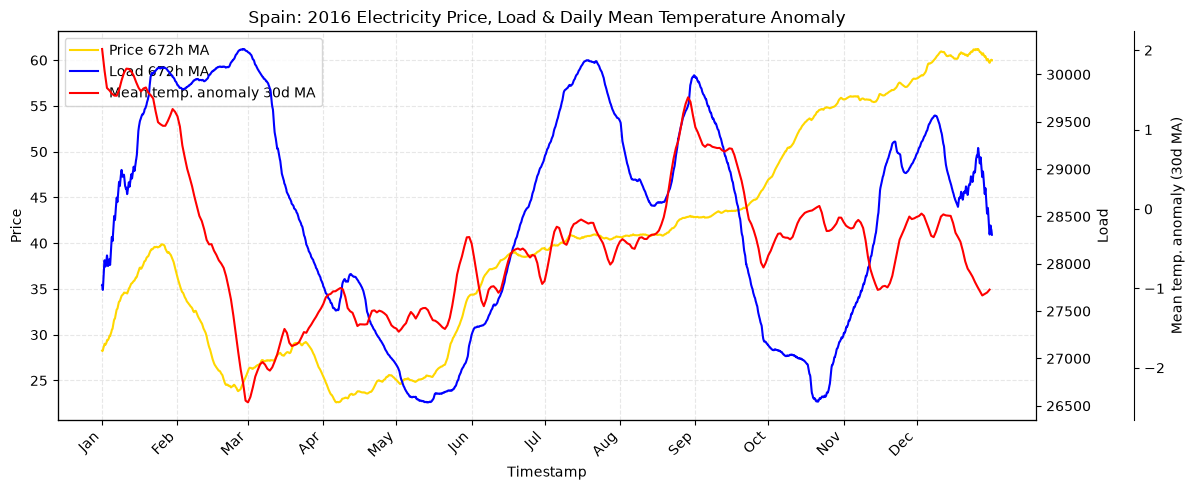

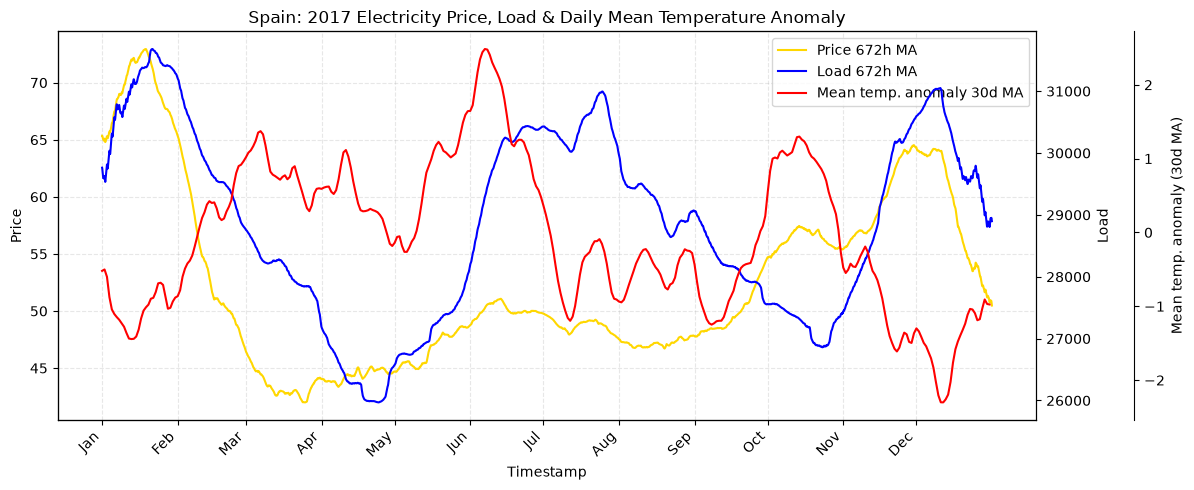

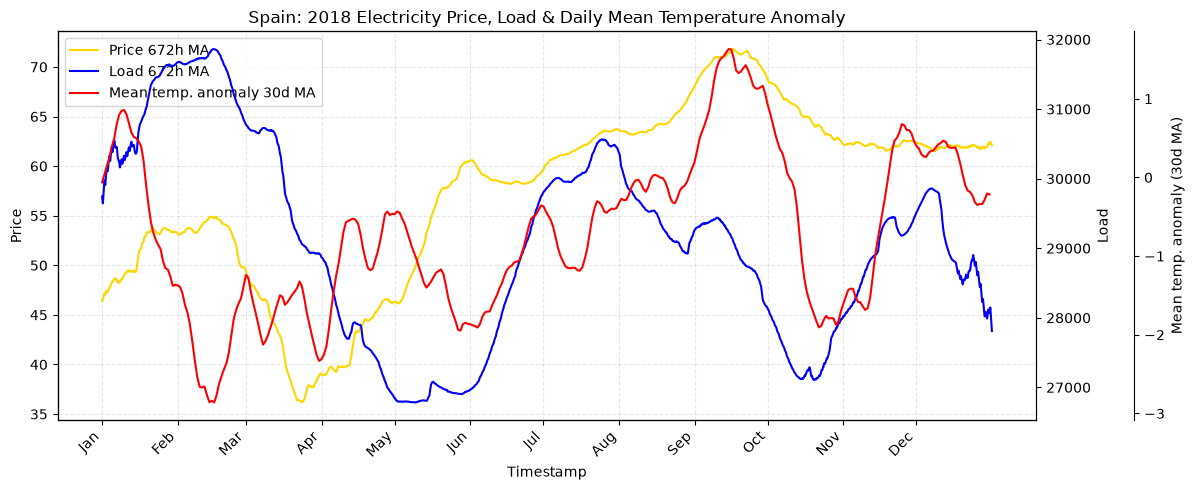

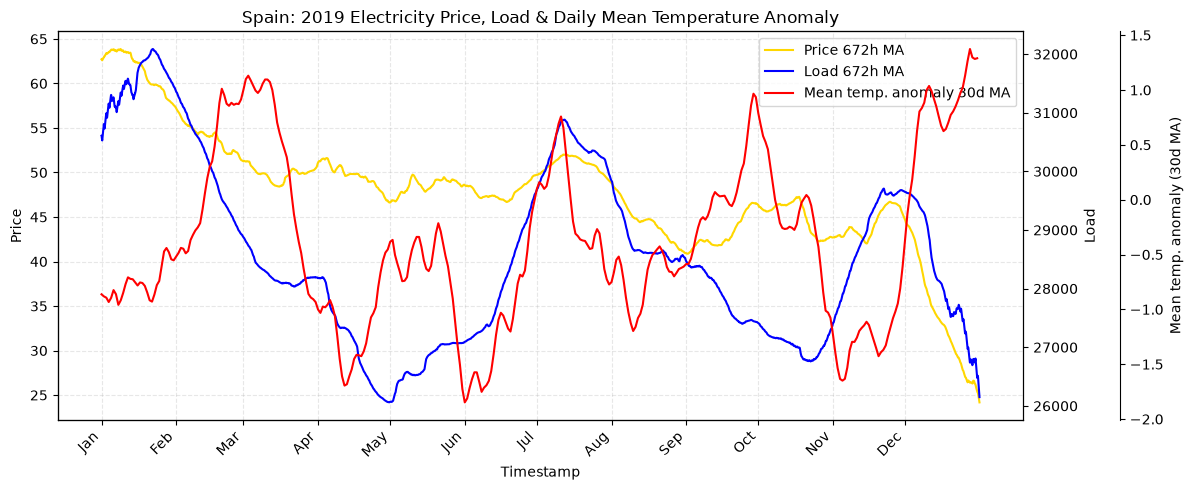

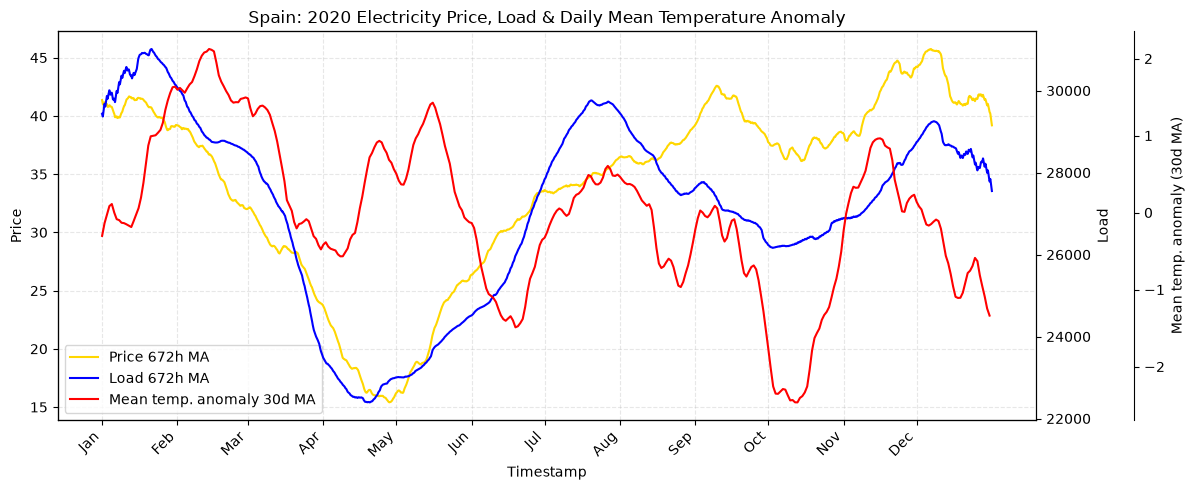

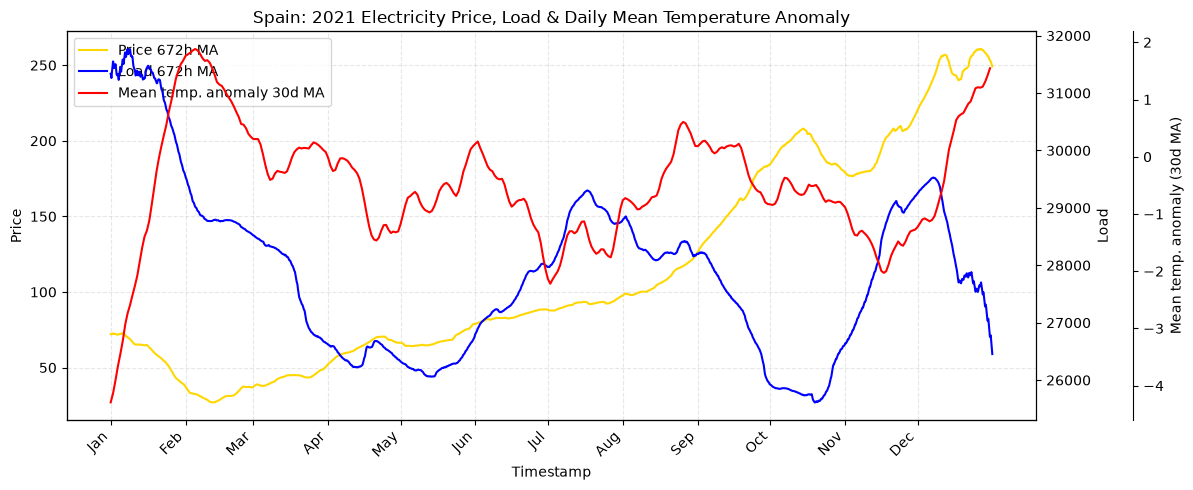

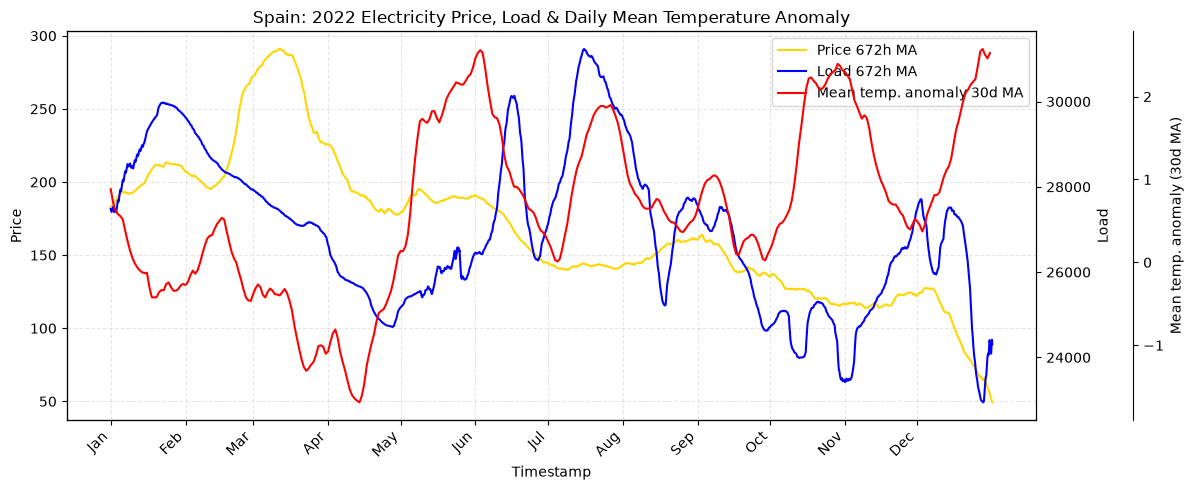

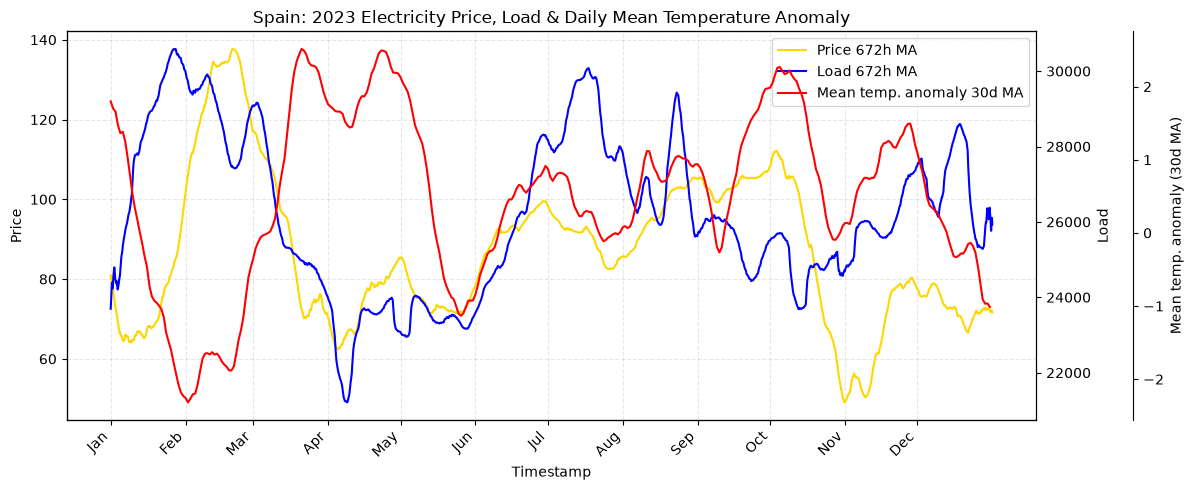

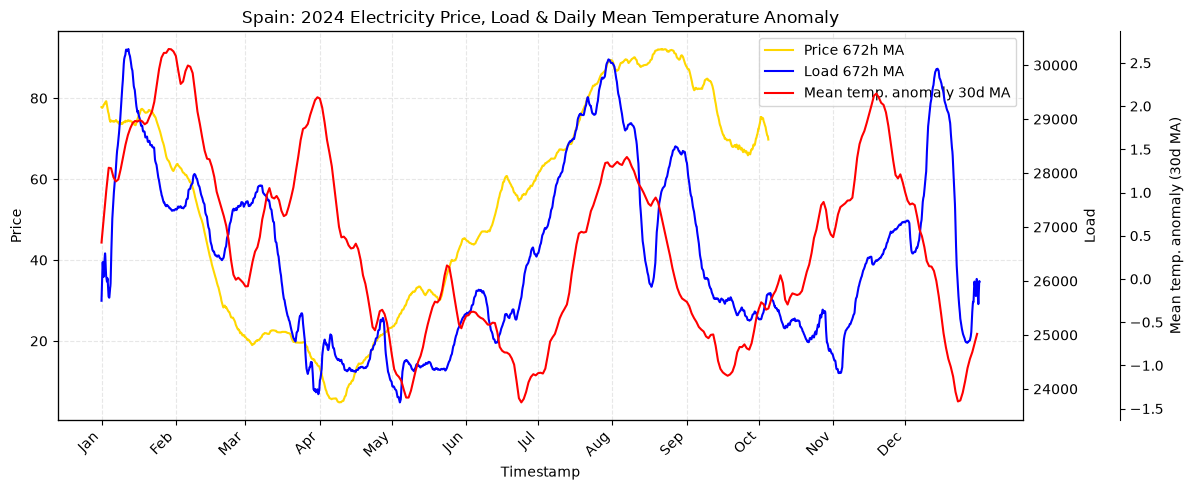

In [11]:
plot_years = range(2015, 2025)
elec_rolling_window = 24 * 28
weather_rolling_window = 30

yearly_electricity_load_weather_plots = {
    year: plot_year_elec_and_tmed(
        year,
        elec_rolling_window=elec_rolling_window,
        weather_rolling_window=weather_rolling_window,
    )
    for year in plot_years
}

In [12]:
def plot_year_elec_and_velm(
    year,
    elec_rolling_window=24 * 28,
    weather_rolling_window=30,
):
    prices_year = pd.read_csv(os.path.join(PRICE_PATH, f"Spain_ENTSO-E_{year}.csv"))
    load_year = pd.read_csv(os.path.join(LOAD_PATH, f"Spain_ENTSO-E_{year}.csv"))

    prices_year["Timestamp"] = pd.to_datetime(prices_year["Timestamp"])
    load_year["Timestamp"] = pd.to_datetime(load_year["Timestamp"])
    prices_year.rename(columns={"Spain": "Price"}, inplace=True)
    load_year.rename(columns={"Spain": "Load"}, inplace=True)

    price_col = prices_year.select_dtypes(include="number").columns[0]
    load_col = load_year.select_dtypes(include="number").columns[0]
    prices_year["Price_MA"] = prices_year[price_col].rolling(
        window=elec_rolling_window, min_periods=1, center=True
    ).mean()
    load_year["Load_MA"] = load_year[load_col].rolling(
        window=elec_rolling_window, min_periods=1, center=True
    ).mean()

    velm_year = velm_anomalies.loc[velm_anomalies.index.year == year]
    velm_mean = velm_year.mean(axis=1)
    velm_mean_ma = velm_mean.rolling(
        window=weather_rolling_window, min_periods=1, center=True
    ).mean()

    fig, ax_price = plt.subplots(figsize=(12, 5))
    line_price, = ax_price.plot(
        prices_year["Timestamp"],
        prices_year["Price_MA"],
        color="gold",
        label=f"Price {elec_rolling_window}h MA",
    )
    ax_price.set_ylabel("Price")
    ax_price.set_xlabel("Timestamp")
    ax_price.grid(True, linestyle="--", alpha=0.3)

    month_ticks = pd.date_range(
        start=f"{year}-01-01", end=f"{year}-12-01", freq="MS"
    )
    ax_price.set_xticks(month_ticks)
    ax_price.set_xticklabels(month_ticks.strftime("%b"), rotation=45, ha="right")

    ax_load = ax_price.twinx()
    line_load, = ax_load.plot(
        load_year["Timestamp"],
        load_year["Load_MA"],
        color="blue",
        label=f"Load {elec_rolling_window}h MA",
    )
    ax_load.set_ylabel("Load")

    ax_velm = ax_price.twinx()
    ax_velm.spines["right"].set_position(("axes", 1.1))
    line_velm, = ax_velm.plot(
        velm_mean_ma.index,
        velm_mean_ma,
        color="grey",
        label=f"Mean wind speed anomaly {weather_rolling_window}d MA",
    )
    ax_velm.set_ylabel(f"Mean wind speed anomaly ({weather_rolling_window}d MA)")
    ax_velm.invert_yaxis()

    ax_price.set_title(
        f"Spain: {year} Electricity Price, Load & Daily Mean Wind Speed Anomaly (inverted)"
    )
    lines = [line_price, line_load, line_velm]
    ax_price.legend(lines, [line.get_label() for line in lines], loc="best")
    fig.tight_layout()
    plt.show()

    return fig, (prices_year, load_year, velm_mean_ma)

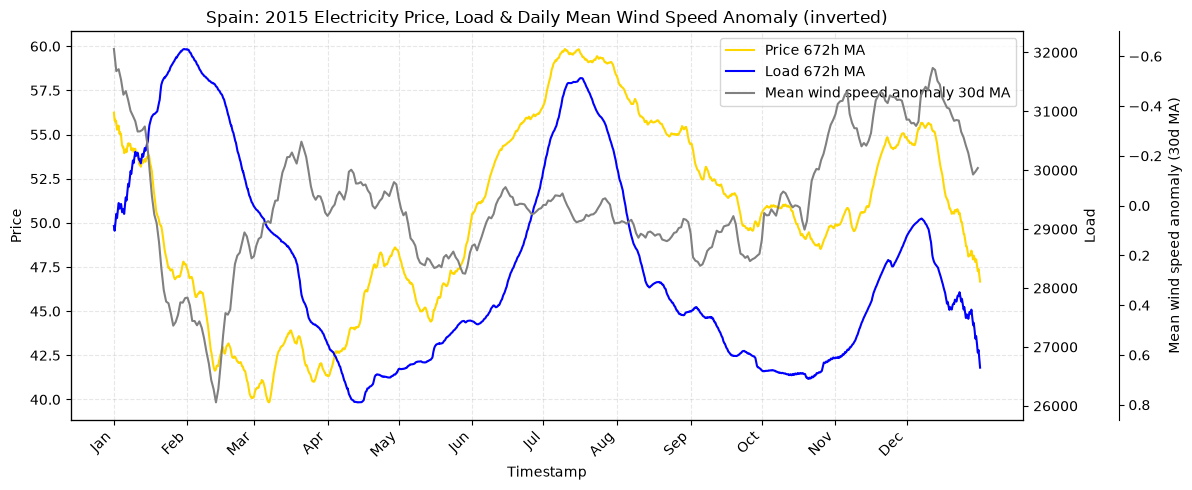

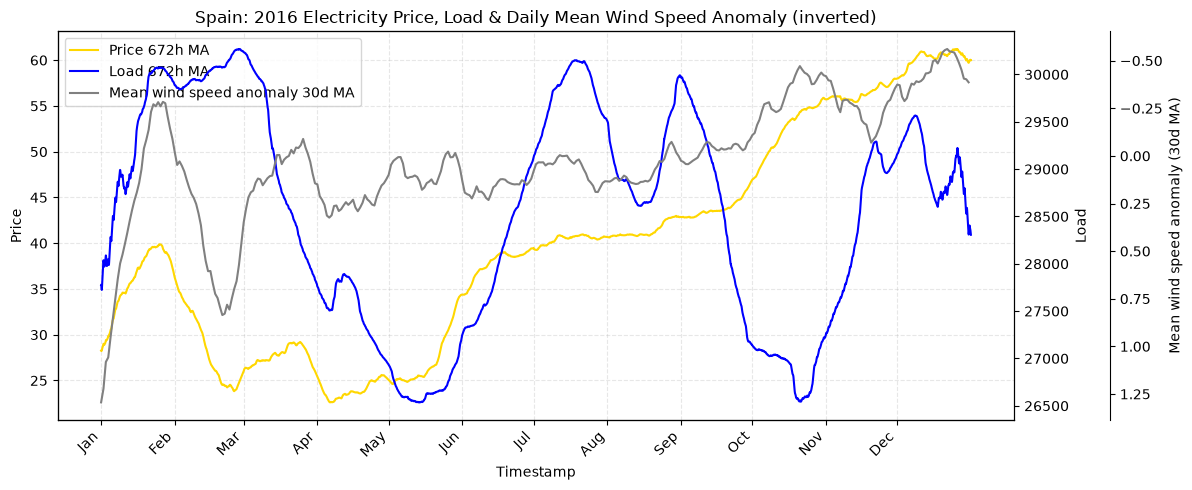

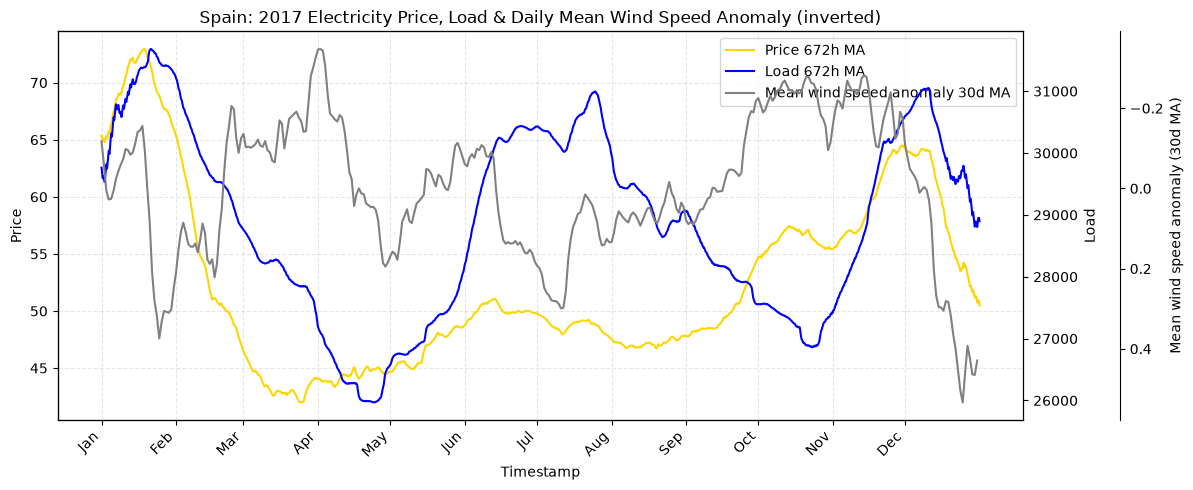

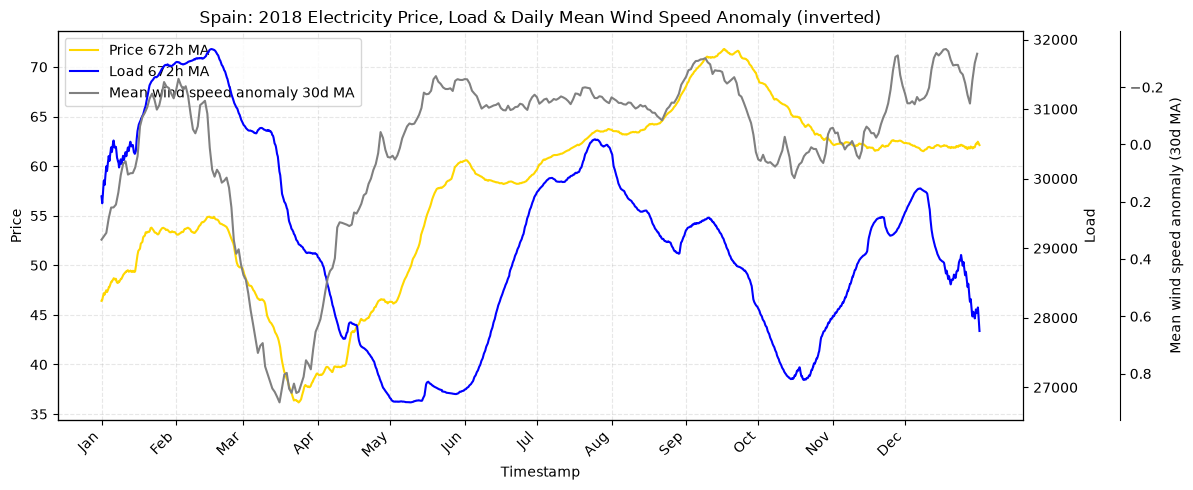

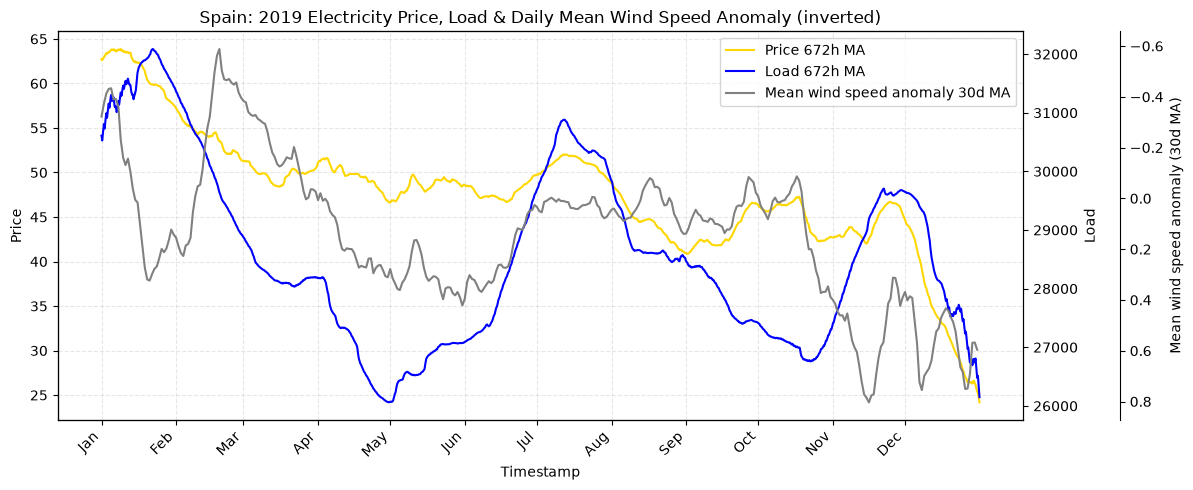

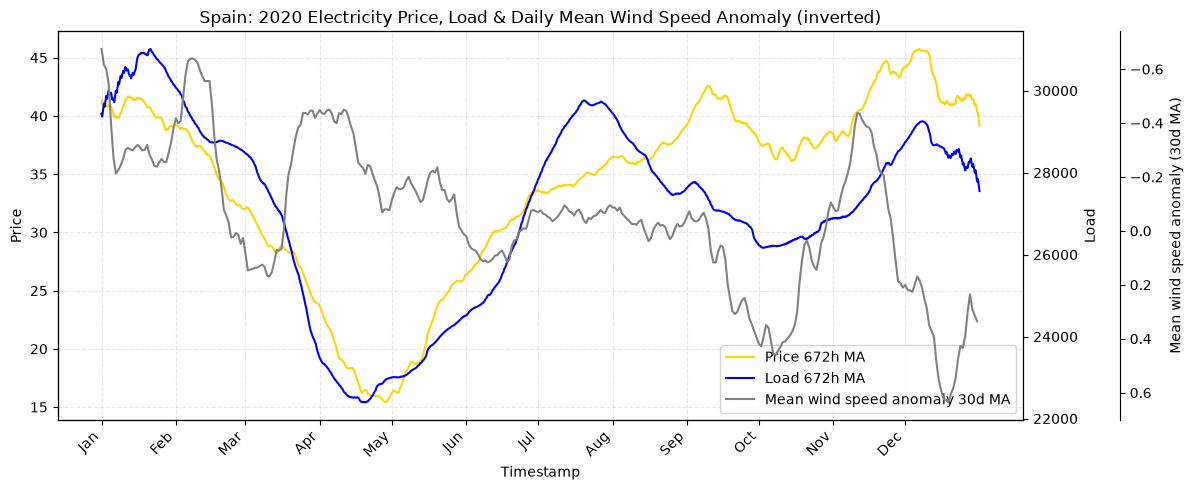

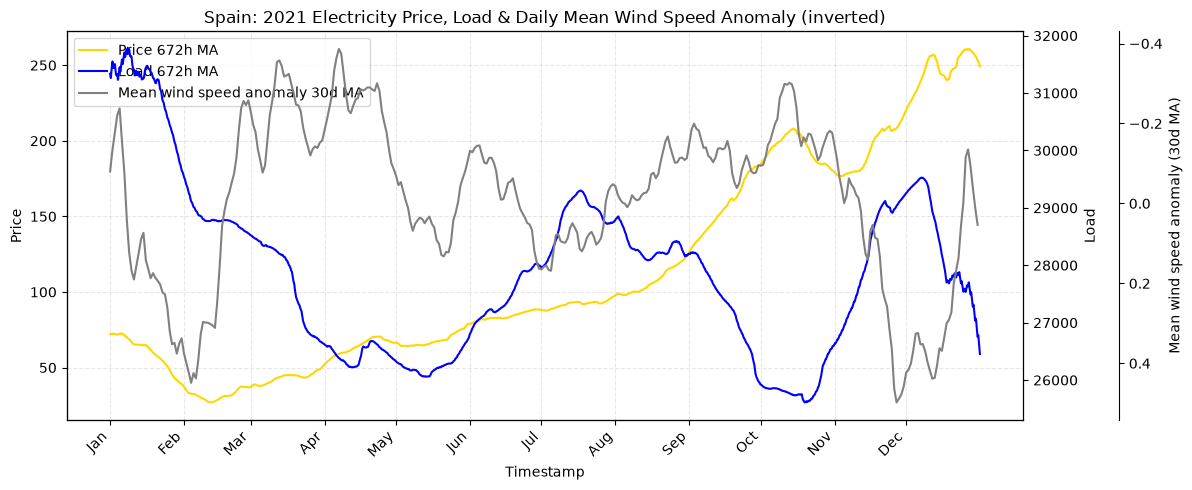

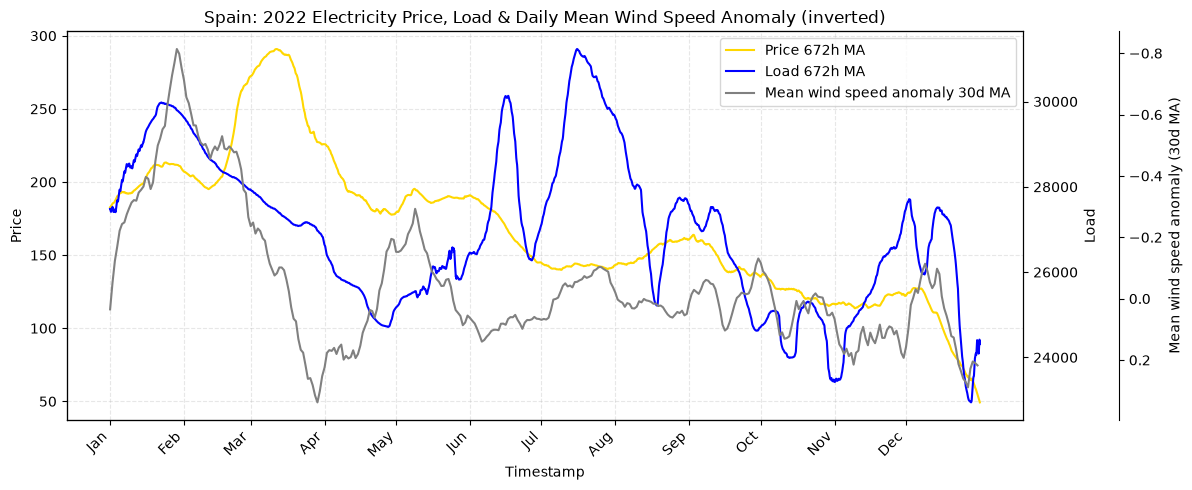

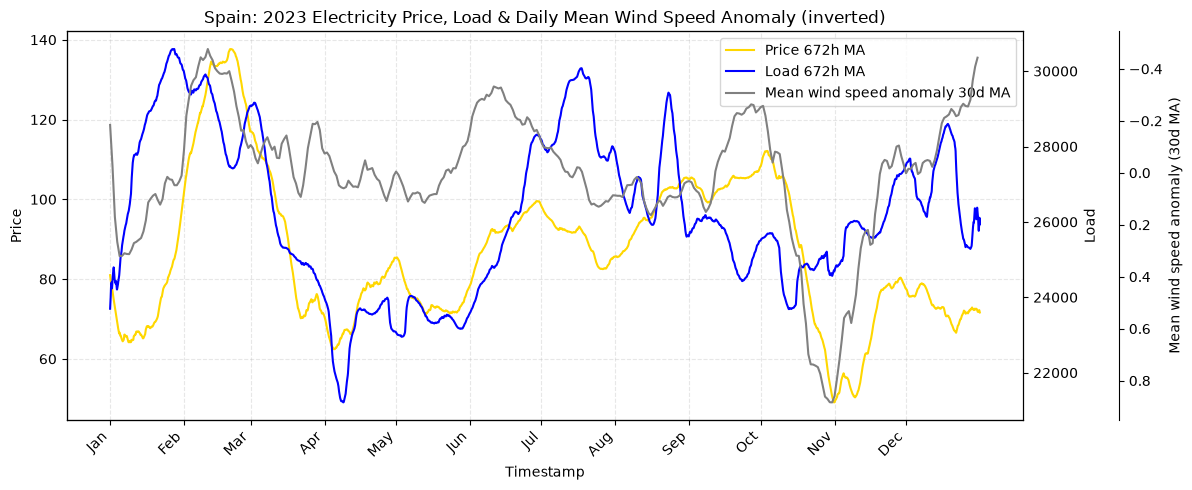

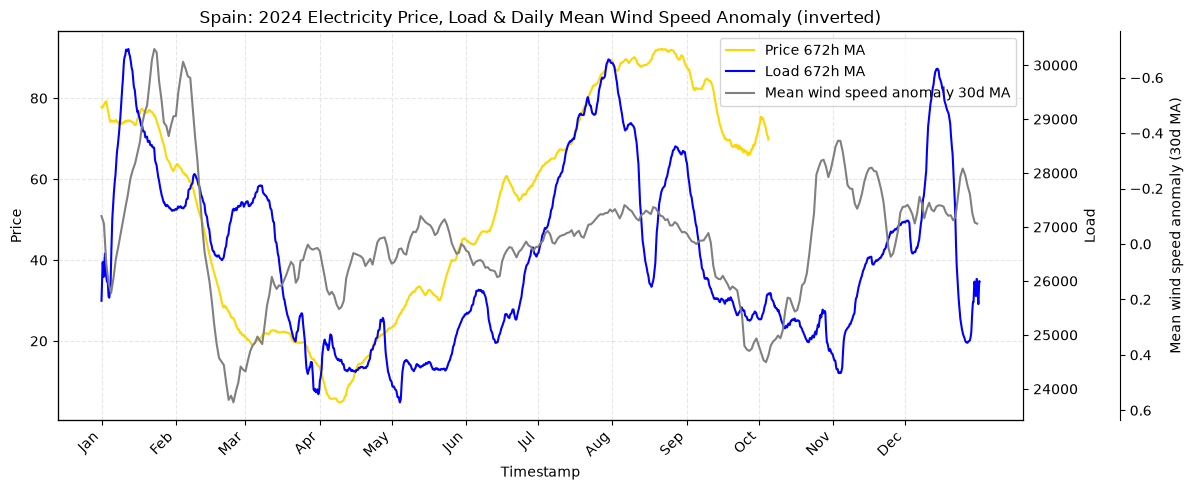

In [13]:
plot_years = range(2015, 2025)
elec_rolling_window = 24 * 28
weather_rolling_window = 30

yearly_electricity_load_weather_plots = {
    year: plot_year_elec_and_velm(
        year,
        elec_rolling_window=elec_rolling_window,
        weather_rolling_window=weather_rolling_window,
    )
    for year in plot_years
}

In [14]:
yearly_price_wind_correlations = {}

for year in range(2015, 2025):
    prices_year = pd.read_csv(
        os.path.join(PRICE_PATH, f"Spain_ENTSO-E_{year}.csv")
    )
    prices_year["Timestamp"] = pd.to_datetime(prices_year["Timestamp"])
    price_col = prices_year.select_dtypes(include="number").columns[0]

    daily_price = (
        prices_year.set_index("Timestamp")[price_col]
        .groupby(pd.Grouper(freq="D"))
        .mean()
    )
    daily_wind = (
        velm_anomalies.loc[velm_anomalies.index.year == year]
        .mean(axis=1)
        .groupby(pd.Grouper(freq="D"))
        .mean()
    )

    expected_days = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365
    date_index = pd.date_range(
        start=f"{year}-01-01",
        end=f"{year}-12-31",
        freq="D",
    )
    daily_price = daily_price.reindex(date_index)
    daily_wind = daily_wind.reindex(date_index)

    daily_price = daily_price.interpolate(method="time").ffill().bfill()
    daily_wind = daily_wind.interpolate(method="time").ffill().bfill()

    assert len(daily_price) == expected_days
    assert len(daily_wind) == expected_days
    assert daily_price.notna().all() and daily_wind.notna().all()

    yearly_price_wind_correlations[year] = daily_price.corr(daily_wind, method="pearson")
    print(
        f"{year}: {yearly_price_wind_correlations[year]:.4f} "
        f"(n={expected_days})"
    )



2015: -0.5233 (n=365)
2016: -0.5948 (n=366)
2017: -0.3770 (n=365)
2018: -0.5901 (n=365)
2019: -0.5228 (n=365)
2020: -0.2405 (n=366)
2021: -0.1459 (n=365)
2022: -0.3599 (n=365)
2023: -0.6152 (n=365)
2024: -0.3226 (n=366)


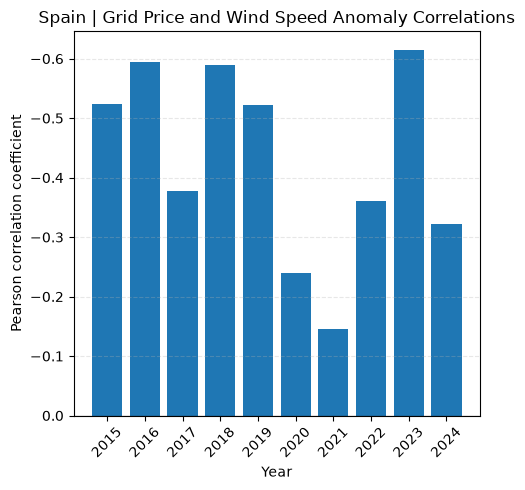

In [21]:
years = list(yearly_price_wind_correlations.keys())
correlations = list(yearly_price_wind_correlations.values())

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(years, correlations, color="tab:blue")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Pearson correlation coefficient")
ax.set_title("Spain | Grid Price and Wind Speed Anomaly Correlations")
ax.set_xticks(years)
ax.tick_params(axis="x", labelrotation=45)
ax.invert_yaxis()
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

In [20]:
rolling_window_days = 3
yearly_price_wind_correlations_7d = {}

for year in range(2015, 2025):
    prices_year = pd.read_csv(
        os.path.join(PRICE_PATH, f"Spain_ENTSO-E_{year}.csv")
    )
    prices_year["Timestamp"] = pd.to_datetime(prices_year["Timestamp"])
    price_col = prices_year.select_dtypes(include="number").columns[0]

    daily_price = (
        prices_year.set_index("Timestamp")[price_col]
        .groupby(pd.Grouper(freq="D"))
        .mean()
    )
    daily_wind = (
        velm_anomalies.loc[velm_anomalies.index.year == year]
        .mean(axis=1)
        .groupby(pd.Grouper(freq="D"))
        .mean()
    )

    expected_days = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365
    date_index = pd.date_range(
        start=f"{year}-01-01",
        end=f"{year}-12-31",
        freq="D",
    )
    daily_price = daily_price.reindex(date_index)
    daily_wind = daily_wind.reindex(date_index)

    daily_price = daily_price.interpolate(method="time").ffill().bfill()
    daily_wind = daily_wind.interpolate(method="time").ffill().bfill()

    daily_price_7d = daily_price.rolling(
        window=rolling_window_days, center=True, min_periods=1
    ).mean()
    daily_wind_7d = daily_wind.rolling(
        window=rolling_window_days, center=True, min_periods=1
    ).mean()

    assert len(daily_price_7d) == expected_days
    assert len(daily_wind_7d) == expected_days
    assert daily_price_7d.notna().all() and daily_wind_7d.notna().all()

    yearly_price_wind_correlations_7d[year] = daily_price_7d.corr(
        daily_wind_7d, method="pearson"
    )
    print(
        f"{year}: {yearly_price_wind_correlations_7d[year]:.4f} "
        f"(n={expected_days}, rolling_window={rolling_window_days}d)"
    )

2015: -0.5117 (n=365, rolling_window=3d)
2016: -0.6070 (n=366, rolling_window=3d)
2017: -0.3191 (n=365, rolling_window=3d)
2018: -0.6088 (n=365, rolling_window=3d)
2019: -0.5146 (n=365, rolling_window=3d)
2020: -0.1544 (n=366, rolling_window=3d)
2021: -0.1094 (n=365, rolling_window=3d)
2022: -0.3839 (n=365, rolling_window=3d)
2023: -0.6325 (n=365, rolling_window=3d)
2024: -0.3237 (n=366, rolling_window=3d)
